# MNIST Image Classification Using CNN

## Project Overview

This project builds a convolutional neural network (CNN) to classify handwritten digits from the MNIST dataset.

The workflow includes loading and inspecting the image data, preprocessing the images, building and training a CNN, evaluating test accuracy, reviewing training performance, and analyzing classification errors with a confusion matrix.


## 1. Import Libraries

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

warnings.filterwarnings("ignore")


## 2. Set Project Paths

In [2]:
CURRENT_DIR = Path.cwd()

# Support running from either the project root or the notebooks folder.
if CURRENT_DIR.name.lower() == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

FIGURES_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"
MODELS_DIR = PROJECT_DIR / "models"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print("Project folders ready:")
print(" - figures/")
print(" - results/")
print(" - models/")


Project folders ready:
 - figures/
 - results/
 - models/


## 3. Load the MNIST Dataset

In [3]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("MNIST dataset loaded successfully.")
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Test labels shape:", y_test.shape)


MNIST dataset loaded successfully.
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Training labels shape: (60000,)
Test labels shape: (10000,)


## 4. Preview Training Images

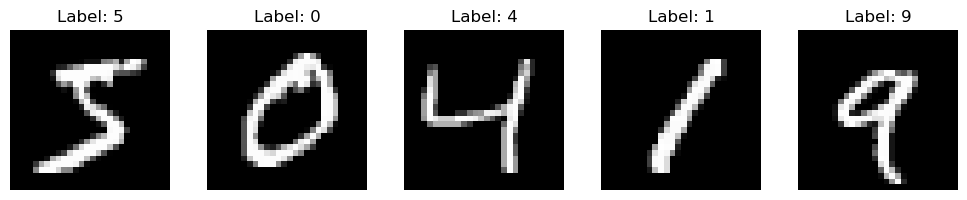

Saved: figures/mnist_sample_training_images.png


In [4]:
fig = plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()

save_path = FIGURES_DIR / "mnist_sample_training_images.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/mnist_sample_training_images.png")


### Observation

The sample images confirm that the dataset contains grayscale handwritten digits and that the corresponding labels match the displayed images.


## 5. Preprocess the Image Data

In [5]:
# Reshape images to include a single grayscale channel and normalize pixels.
X_train_cnn = (
    X_train.reshape(-1, 28, 28, 1)
    .astype("float32") / 255.0
)

X_test_cnn = (
    X_test.reshape(-1, 28, 28, 1)
    .astype("float32") / 255.0
)

# One-hot encode the class labels.
num_classes = 10

y_train_cat = keras.utils.to_categorical(
    y_train,
    num_classes
)

y_test_cat = keras.utils.to_categorical(
    y_test,
    num_classes
)

print("Data preprocessing completed successfully.")
print("Training input shape:", X_train_cnn.shape)
print("Test input shape:", X_test_cnn.shape)


Data preprocessing completed successfully.
Training input shape: (60000, 28, 28, 1)
Test input shape: (10000, 28, 28, 1)


## 6. Build the CNN Model

In [6]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu"
    ),
    layers.Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu"
    ),
    layers.MaxPooling2D(
        pool_size=(2, 2)
    ),
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense(
        128,
        activation="relu"
    ),
    layers.Dropout(0.5),
    layers.Dense(
        num_classes,
        activation="softmax"
    )
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 26, 26, 32)        320       
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 64)        18496     
                                                                 
 max_pooling2d (MaxPooling2  (None, 12, 12, 64)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 12, 12, 64)        0         
                                                                 
 flatten (Flatten)           (None, 9216)              0         
                                                                 
 dense (Dense)               (None, 128)               1179776   
                                                        

## 7. Train the CNN Model

In [7]:
history = model.fit(
    X_train_cnn,
    y_train_cat,
    validation_split=0.10,
    epochs=5,
    batch_size=128,
    verbose=1
)

print("CNN training completed successfully.")


Epoch 1/5
422/422 [==============================] - 133s 312ms/step - loss: 0.2642 - accuracy: 0.9191 - val_loss: 0.0555 - val_accuracy: 0.9843
Epoch 2/5
422/422 [==============================] - 148s 351ms/step - loss: 0.0877 - accuracy: 0.9736 - val_loss: 0.0452 - val_accuracy: 0.9863
Epoch 3/5
422/422 [==============================] - 142s 336ms/step - loss: 0.0675 - accuracy: 0.9804 - val_loss: 0.0400 - val_accuracy: 0.9890
Epoch 4/5
422/422 [==============================] - 104s 247ms/step - loss: 0.0535 - accuracy: 0.9837 - val_loss: 0.0331 - val_accuracy: 0.9900
Epoch 5/5
422/422 [==============================] - 187s 443ms/step - loss: 0.0460 - accuracy: 0.9857 - val_loss: 0.0375 - val_accuracy: 0.9898
CNN training completed successfully.


## 8. Review Training Performance

In [8]:
history_df = pd.DataFrame(history.history)
history_df.index = np.arange(
    1,
    len(history_df) + 1
)
history_df.index.name = "Epoch"

history_df.to_csv(
    RESULTS_DIR / "training_history.csv"
)

display(history_df.round(4))

print("Saved: results/training_history.csv")


,loss,accuracy,val_loss,val_accuracy
Epoch,,,,
1,0.2642,0.9191,0.0555,0.9843
2,0.0877,0.9736,0.0452,0.9863
3,0.0675,0.9804,0.0400,0.9890
4,0.0535,0.9837,0.0331,0.9900
5,0.0460,0.9857,0.0375,0.9898


Saved: results/training_history.csv


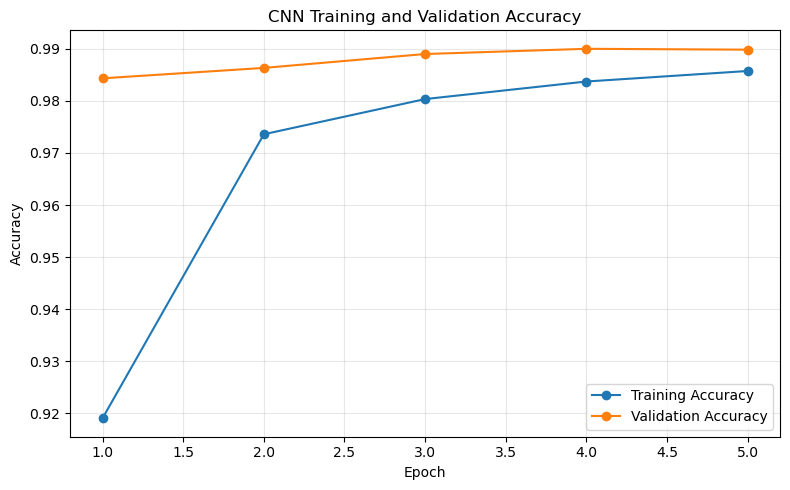

Saved: figures/training_validation_accuracy.png


In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index,
    history_df["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_df.index,
    history_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

save_path = FIGURES_DIR / "training_validation_accuracy.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/training_validation_accuracy.png")


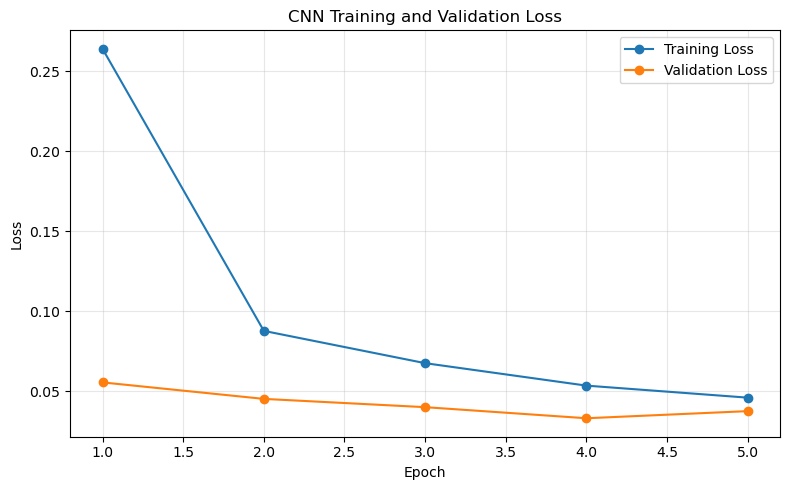

Saved: figures/training_validation_loss.png


In [10]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_df.index,
    history_df["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_df.index,
    history_df["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

save_path = FIGURES_DIR / "training_validation_loss.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/training_validation_loss.png")


## 9. Evaluate Test Accuracy

In [11]:
test_loss, test_accuracy = model.evaluate(
    X_test_cnn,
    y_test_cat,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Loss: 0.0329
Test Accuracy: 0.9900


In [12]:
model_metrics = pd.DataFrame({
    "Metric": [
        "Test Loss",
        "Test Accuracy"
    ],
    "Value": [
        test_loss,
        test_accuracy
    ]
})

model_metrics.to_csv(
    RESULTS_DIR / "model_metrics.csv",
    index=False
)

display(
    model_metrics.style.format({
        "Value": "{:.4f}"
    })
)

print("Saved: results/model_metrics.csv")


,Metric,Value
0,Test Loss,0.0329
1,Test Accuracy,0.9900


Saved: results/model_metrics.csv


## 10. Generate the Confusion Matrix

In [13]:
y_pred_prob = model.predict(
    X_test_cnn,
    verbose=0
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[ 978    0    0    0    0    0    0    1    1    0]
 [   0 1134    1    0    0    0    0    0    0    0]
 [   1    2 1022    1    1    0    0    5    0    0]
 [   0    0    2 1005    0    1    0    0    2    0]
 [   0    0    0    0  977    0    2    0    0    3]
 [   2    0    0    7    0  877    4    0    2    0]
 [   8    2    0    1    1    1  945    0    0    0]
 [   0    2    6    2    0    0    0 1016    1    1]
 [   5    0    2    1    1    0    1    2  960    2]
 [   4    3    0    0    6    1    0    5    4  986]]


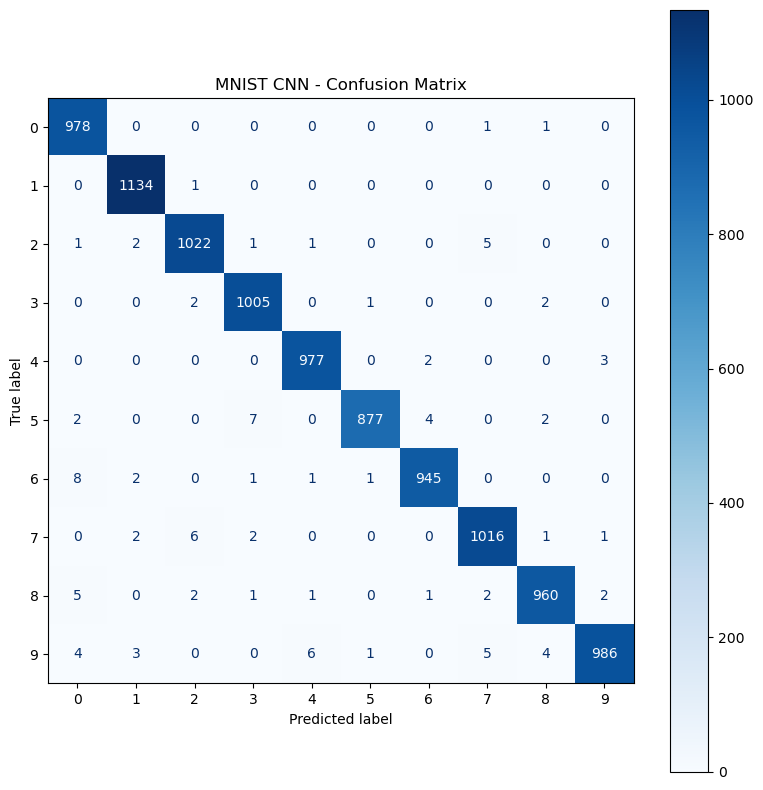

Saved: figures/mnist_confusion_matrix.png


In [14]:
fig, ax = plt.subplots(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax
)

plt.title("MNIST CNN - Confusion Matrix")
plt.tight_layout()

save_path = FIGURES_DIR / "mnist_confusion_matrix.png"
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved: figures/mnist_confusion_matrix.png")


### Observation

Most predictions appear along the diagonal of the confusion matrix, indicating that the CNN correctly classifies the majority of handwritten digits. The remaining errors generally occur between digits with similar handwritten shapes.


## 11. Save the Trained Model

In [15]:
model_path = MODELS_DIR / "mnist_cnn_model.keras"

model.save(model_path)

print("Saved: models/mnist_cnn_model.keras")


Saved: models/mnist_cnn_model.keras


## 12. Saved Project Outputs

In [16]:
print("Figures:")
for file in sorted(FIGURES_DIR.glob("*.png")):
    print(" -", f"figures/{file.name}")

print("\nResults:")
for file in sorted(RESULTS_DIR.glob("*.csv")):
    print(" -", f"results/{file.name}")

print("\nModels:")
for file in sorted(MODELS_DIR.glob("*")):
    if file.is_file():
        print(" -", f"models/{file.name}")


Figures:
 - figures/mnist_confusion_matrix.png
 - figures/mnist_sample_training_images.png
 - figures/training_validation_accuracy.png
 - figures/training_validation_loss.png

Results:
 - results/model_metrics.csv
 - results/training_history.csv

Models:
 - models/mnist_cnn_model.keras


## Conclusion

The CNN provides a strong approach for handwritten-digit recognition using the MNIST dataset. The model learns visual patterns directly from the image pixels and is evaluated using test accuracy, training history, and a confusion matrix.

The project demonstrates a complete deep-learning image-classification workflow, including preprocessing, CNN architecture design, model training, evaluation, visualization, and model persistence.
